# Analyse exploratoire du catalogue Netflix

Ce projet propose une analyse exploratoire du catalogue de contenus disponibles sur la plateforme Netflix.  
L'objectif est d'examiner la structure du catalogue, les types de contenus proposés, ainsi que leur évolution au 
fil du temps à l'aide de visualisations de données.




## Etape 1 : Accueil 

### - Contexte et objectifs

Netflix est aujourd’hui l’une des plateformes de streaming les plus importantes au monde.  
Elle propose un catalogue très diversifié comprenant des films et des séries provenant de nombreux pays et couvrant différents genres.

Dans ce contexte, il est intéressant d’analyser la composition du catalogue Netflix afin de mieux comprendre les types de contenus proposés aux utilisateurs.  
Cette analyse exploratoire vise à identifier les tendances principales du catalogue, notamment en termes de genres dominants, de pays producteurs et de durée des films.

L’objectif de ce projet est donc d’explorer ces données à l’aide de visualisations afin de mettre en évidence les caractéristiques principales du catalogue et son évolution dans le temps.


### - Source des données

Les données utilisées proviennent d’un dataset public disponible sur la plateforme Kaggle intitulé Netflix Movies and TV Shows . 
Ce dataset contient des informations sur les contenus présents sur Netflix, notamment le type de contenu (film ou série),
le pays de production, l’année de sortie, le genre, la durée et la classification d’âge.

Ces données permettent de réaliser une analyse exploratoire afin d’identifier les principales tendances du catalogue
Netflix.


### - Question de recherche

Cette analyse cherche à répondre à la question suivante :

Comment la composition du catalogue Netflix évolue-t-elle au fil du temps et quels types de contenus dominent la plateforme en termes de genres, de pays producteurs et de caractéristiques des films (durée) ?

### - Intérêt de l'analyse

Comprendre la composition du catalogue Netflix permet d’identifier les stratégies de contenu adoptées par la plateforme.  
L’analyse des genres, des pays producteurs et de l’évolution des contenus permet également de mieux comprendre les 
préférences du public et les tendances de l’industrie du streaming.

Cette étude permet ainsi de mettre en évidence les caractéristiques principales du catalogue et son évolution au 
fil des années.


## Etape 2 :Exploration et visualisations
### - Importation des bibliothèques
Nous importons les bibliothèques nécessaires pour manipuler et analyser les données.

In [28]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


### - Chargement du dataset et  Aperçu du dataset
Le dataset Netflix est chargé dans un DataFrame pandas afin de pouvoir analyser les données.
les premières lignes sont affichés  afin de comprendre la structure des données.


In [29]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### - Dimensions du dataset
on vérifie le nombre de lignes et de colonnes du dataset


In [31]:
df.shape


(8807, 12)

### - Variables disponibles
on affiche la liste des colonnes présentes dans le dataset


In [32]:
df.columns


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

### Description des colonnes principales

- **type** : type de contenu (Film ou Série).
- **title** : titre du contenu.
- **director** : réalisateur du film ou de la série.
- **country** : pays de production.
- **release_year** : année de sortie du contenu.
- **rating** : classification d'âge.
- **duration** : durée du film ou nombre de saisons pour les séries.
- **listed_in** : genre du contenu.


### - Les Indicateurs clés du dataset :KPI

Afin de résumer les caractéristiques principales du catalogue Netflix, on calcule plusieurs indicateurs clés.  
Ces KPI permettent de mieux comprendre la structure du catalogue, la place occupée par les films et les séries, ainsi
que certaines caractéristiques des contenus comme leur durée et leur période de sortie.

In [87]:
# Préparation des données pour les KPI

# Nombre total de contenus
total_content = df.shape[0]

# Nombre de films et de séries
total_movies = df[df['type'] == 'Movie'].shape[0]
total_series = df[df['type'] == 'TV Show'].shape[0]

# Pourcentages
pct_movies = (total_movies / total_content) * 100
pct_series = (total_series / total_content) * 100

# Préparation de la durée des films
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)')
df_movies = df_movies.dropna(subset=['duration_min'])
df_movies['duration_min'] = df_movies['duration_min'].astype(int)

# Durée moyenne et médiane
avg_duration = round(df_movies['duration_min'].mean(), 2)
median_duration = df_movies['duration_min'].median()

# Année de sortie la plus récente
max_release_year = df['release_year'].max()

# Année moyenne de sortie
avg_release_year = round(df['release_year'].mean(), 0)

# Création d'un tableau de KPI
kpi_table = pd.DataFrame({
    "Indicateur": [
        "Nombre total de contenus",
        "Pourcentage de films",
        "Pourcentage de séries",
        "Durée moyenne des films",
        "Durée médiane des films",
        "Année moyenne de sortie",
        "Année de sortie la plus récente"
    ],
    "Valeur": [
        total_content,
        f"{pct_movies:.2f} %",
        f"{pct_series:.2f} %",
        f"{avg_duration} minutes",
        f"{median_duration} minutes",
        int(avg_release_year),
        max_release_year
    ]
})

# Affichage des KPI
kpi_table

,Indicateur,Valeur
0,Nombre total de contenus,8807
1,Pourcentage de films,69.62 %
2,Pourcentage de séries,30.38 %
3,Durée moyenne des films,99.58 minutes
4,Durée médiane des films,98.0 minutes
5,Année moyenne de sortie,2014
6,Année de sortie la plus récente,2021


#### Interprétation

Ces indicateurs montrent que le catalogue Netflix est majoritairement composé de films, qui représentent la plus grande part 
des contenus disponibles.  
La durée moyenne et la durée médiane des films sont proches, ce qui indique que la majorité des films suivent un format relativement 
standard.  
Enfin, la présence de contenus récents confirme que le catalogue s’inscrit dans une dynamique d’évolution continue.

### - Types de variables
on vérifie le type de chaque colonne afin de comprendre comment les données sont stockées


In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### - Analyse des valeurs manquantes
on vérifie combien de valeurs manquent dans chaque colonne du dataset


In [34]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Interprétation
Le dataset contient 8807 observations et 12 variables.
Certaines colonnes contiennent des valeurs manquantes :

- director : beaucoup de valeurs nulles (2634)
- cast : quelques valeurs manquantes (environ 825)
- country : certaines valeurs manquantes (environ 831)
- date_added : très peu de valeurs manquantes

Les variables complètes comme type, title, release_year,show_id, listed_in et description pourront être utilisées facilement pour l’analyse.

Dans le cadre de ce projet , les variables les plus pertinentes pour l’analyse seront :

- type : permet de distinguer les films et les séries
- release_year : permet d’analyser l’évolution du catalogue dans le temps
- country : permet d’étudier la répartition géographique des contenus
- rating : permet d’analyser la classification des contenus
- duration : permet d’étudier la durée des films ou le nombre de saisons
- listed_in : permet d’analyser les genres des contenus

Ces variables seront utilisées dans les prochaines étapes pour réaliser les visualisations et les analyses exploratoires.

###  - Distribution des types de contenus
on analyse la répartition des contenus entre les films et les séries


In [65]:
df['type'].value_counts()


type
Movie      6131
TV Show    2676
Name: count, dtype: int64

#### Interprétation

Le dataset contient 6131 films et 2676 séries TV.
On observe donc que les films représentent la majorité du catalogue Netflix dans ce dataset.

Cette première analyse permet de comprendre la composition générale du catalogue avant de poursuivre l’exploration avec d’autres variables.

### Visualisation 

### - Visualisation de la répartition des contenus
on utilise un graphique pour visualiser la proportion de films et de séries dans le catalogue Netflix 


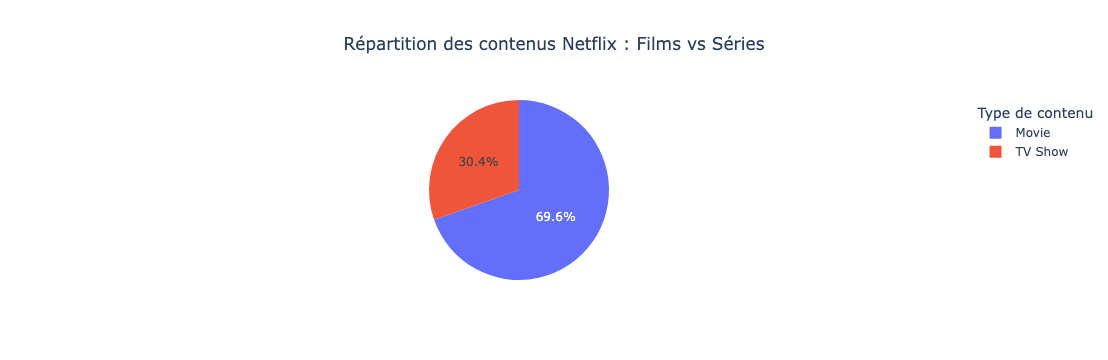

In [36]:
type_counts = df['type'].value_counts().reset_index()
type_counts.columns = ['Type de contenu', 'Nombre']

fig = px.pie(
    type_counts,
    names='Type de contenu',
    values='Nombre',
    title='Répartition des contenus Netflix : Films vs Séries',
)

fig.update_layout(
    title_x=0.5,  # centre le titre
    legend_title="Type de contenu"
)

fig.show()


#### Interprétation

La majorité des contenus du dataset Netflix sont des films (environ 70 %), tandis que les séries représentent environ 30 % du catalogue.
Cela montre que les films dominent dans cette base de données.

### - Évolution des films et séries dans le catalogue Netflix

on analyse comment la production de films et de séries a évolué au fil des années dans le catalogue Netflix.
Cette visualisation permet de comprendre la stratégie de contenu de la plateforme.

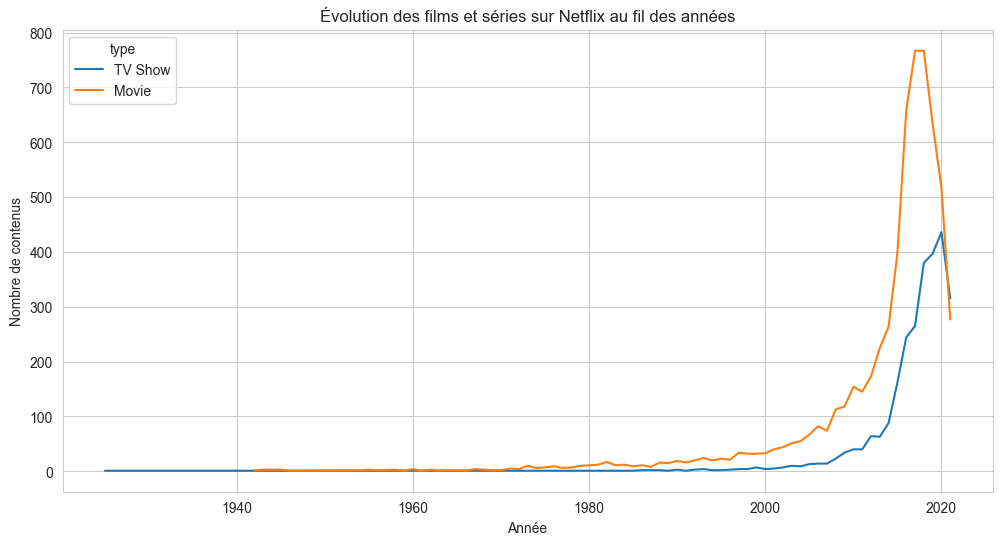

In [69]:
# Nombre de contenus par année et par type
content_type_year = df.groupby(['release_year', 'type']).size().reset_index(name='count')

# Création du graphique
plt.figure(figsize=(12,6))
sns.lineplot(data=content_type_year, x='release_year', y='count', hue='type')

plt.title("Évolution des films et séries sur Netflix au fil des années")
plt.xlabel("Année")
plt.ylabel("Nombre de contenus")
plt.show()

#### Interprétation

Ce graphique montre l’évolution du nombre de films et de séries ajoutés au catalogue Netflix au fil des années.

On observe que le nombre de contenus reste relativement faible jusqu’aux années 2000. À partir de 2010, le catalogue augmente
fortement, avec une croissance très rapide des films.

L’analyse de l’évolution des contenus par type montre que les films ont longtemps dominé le catalogue Netflix. Cependant, à partir 
des années 2015, la production de séries connaît une forte croissance. Cette tendance reflète la stratégie de la plateforme qui mise
de plus en plus sur les séries pour fidéliser les abonnés et prolonger l’engagement des utilisateurs.

On remarque enfin une baisse après 2020, qui peut être liée au fait que les données récentes sont encore incomplètes dans le dataset.

### - Genres les plus présents sur Netflix
on analyse les genres les plus représentés dans le catalogue Netflix.


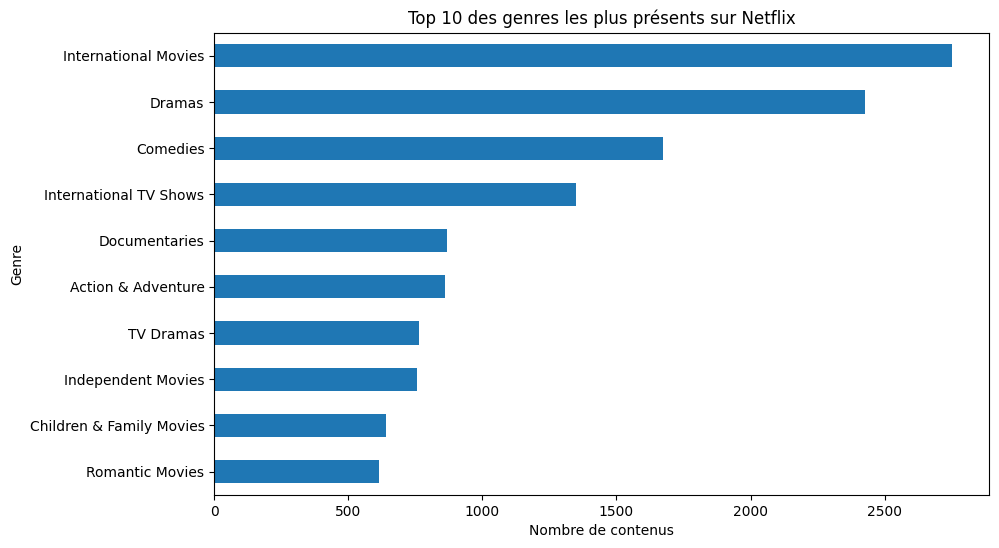

In [51]:
# Séparer les genres (car plusieurs genres peuvent être dans une cellule)
genres = df['listed_in'].str.split(', ').explode()

# Compter les genres les plus fréquents
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind='barh')

plt.title("Top 10 des genres les plus présents sur Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Genre")

plt.show()



#### Interpretation 
Ce graphique présente les 10 genres les plus présents dans le catalogue Netflix.

On observe que International Movies est le genre le plus représenté, suivi par Dramas et Comedies. 
Cela montre que Netflix propose une grande diversité de contenus internationaux et privilégie des genres populaires auprès d’un large public.

Les genres comme Documentaries, Action & Adventure et TV Dramas occupent également une place importante dans le catalogue. À l’inverse, 
certains genres comme Children & Family Movies ou Romantic Movies sont moins représentés parmi les contenus les plus fréquents.

Ces résultats suggèrent que Netflix cherche à offrir un catalogue varié, avec une forte présence de contenus internationaux et de 
genres largement appréciés par les utilisateurs.

### - Pays produisant le plus de contenus Netflix
on analyse les pays les plus représentés dans le catalogue Netflix.


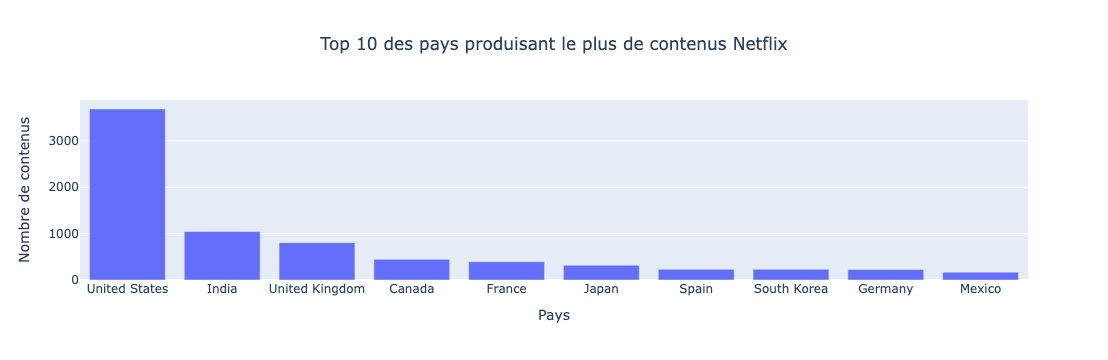

In [40]:
countries = df['country'].dropna().str.split(', ').explode()

top_countries = countries.value_counts().head(10).reset_index()
top_countries.columns = ['Pays', 'Nombre de contenus']

fig = px.bar(
    top_countries,
    x='Pays',
    y='Nombre de contenus',
    title="Top 10 des pays produisant le plus de contenus Netflix"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Pays",
    yaxis_title="Nombre de contenus"
)

fig.show()


#### Interprétation

Les États-Unis dominent largement la production de contenus présents dans le catalogue Netflix.
On observe également une contribution importante de pays comme l’Inde, le Royaume-Uni et le Canada, ce qui montre la diversité géographique
des productions disponibles sur la plateforme.

### - Corrélation entre les variables numériques
Afin d’identifier d’éventuelles relations entre les variables numériques du dataset, nous analysons la corrélation entre 
l’année de sortie des films et leur durée. La matrice de corrélation permet d’évaluer la force et la direction de la relation entre
ces variables.

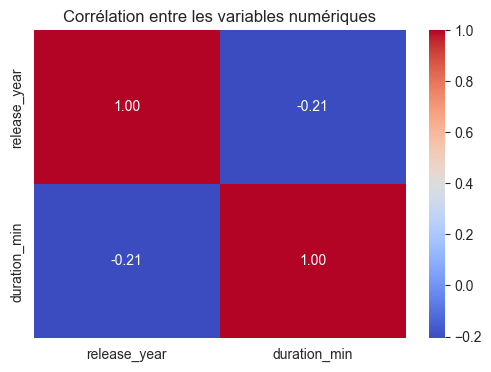

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des variables numériques
corr_data = df_movies[['release_year','duration_min']]

# Calcul de la matrice de corrélation
corr_matrix = corr_data.corr()

# Création de la heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matrice de corrélation entre l'année de sortie et la durée des films")
plt.show()

#### Interprétation

La heatmap montre une corrélation faible et légèrement négative (-0.21) entre l’année de sortie et la durée des films. 

Cela suggère que la durée des films n’augmente pas significativement avec le temps. Les films plus récents ne sont donc pas 
nécessairement plus longs que les anciens. La durée des films semble rester relativement stable dans le catalogue Netflix au fil 
des années.

### Distribution de la durée des films

Afin de mieux comprendre les caractéristiques des films présents dans le catalogue Netflix, on analyse la distribution de leur durée.  
Cette visualisation permet d’identifier les durées les plus fréquentes ainsi que la présence éventuelle de films très courts ou très longs.

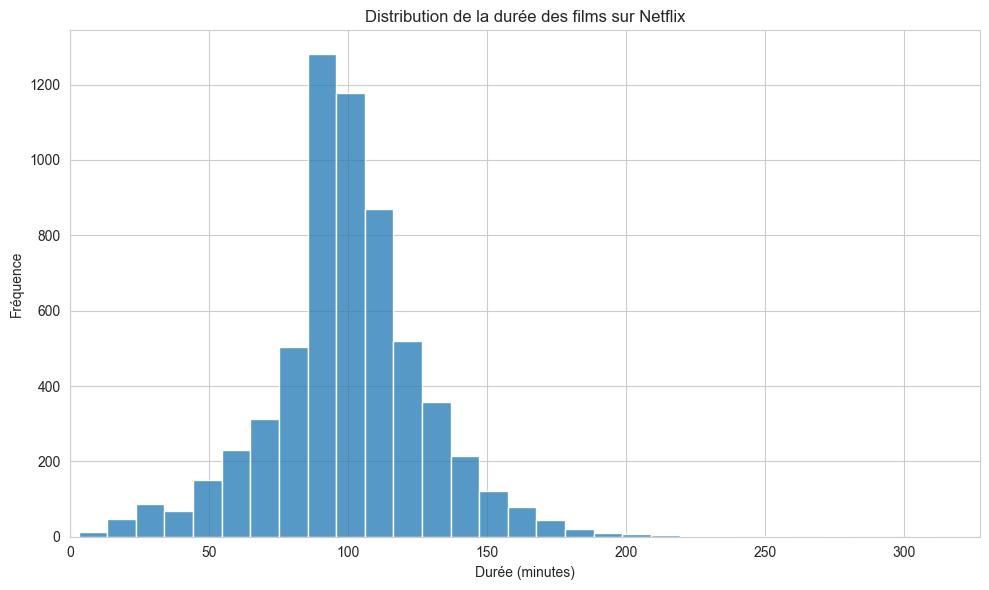

In [73]:
# Filtrer uniquement les films
df_movies = df[df['type'] == 'Movie'].copy()

# Extraire les nombres de la durée
df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)')

# Supprimer les valeurs manquantes
df_movies = df_movies.dropna(subset=['duration_min'])

# Convertir en entier
df_movies['duration_min'] = df_movies['duration_min'].astype(int)

# Histogramme
plt.figure(figsize=(10,6))
sns.histplot(df_movies['duration_min'], bins=30)

# Titres et labels
plt.title("Distribution de la durée des films sur Netflix")
plt.xlabel("Durée (minutes)")
plt.ylabel("Fréquence")

# Ajustement de l'affichage
plt.xlim(left=0)
plt.tight_layout()

plt.show()

#### Interprétation

L’histogramme montre que la majorité des films présents sur Netflix ont une durée comprise entre environ 80 et 120 minutes.

Cette concentration autour de 90 à 110 minutes correspond au format classique du cinéma.  
Les films très courts ou très longs sont plus rares, ce qui indique que la plateforme propose majoritairement des films de durée standard.

### - tableau de synthèse

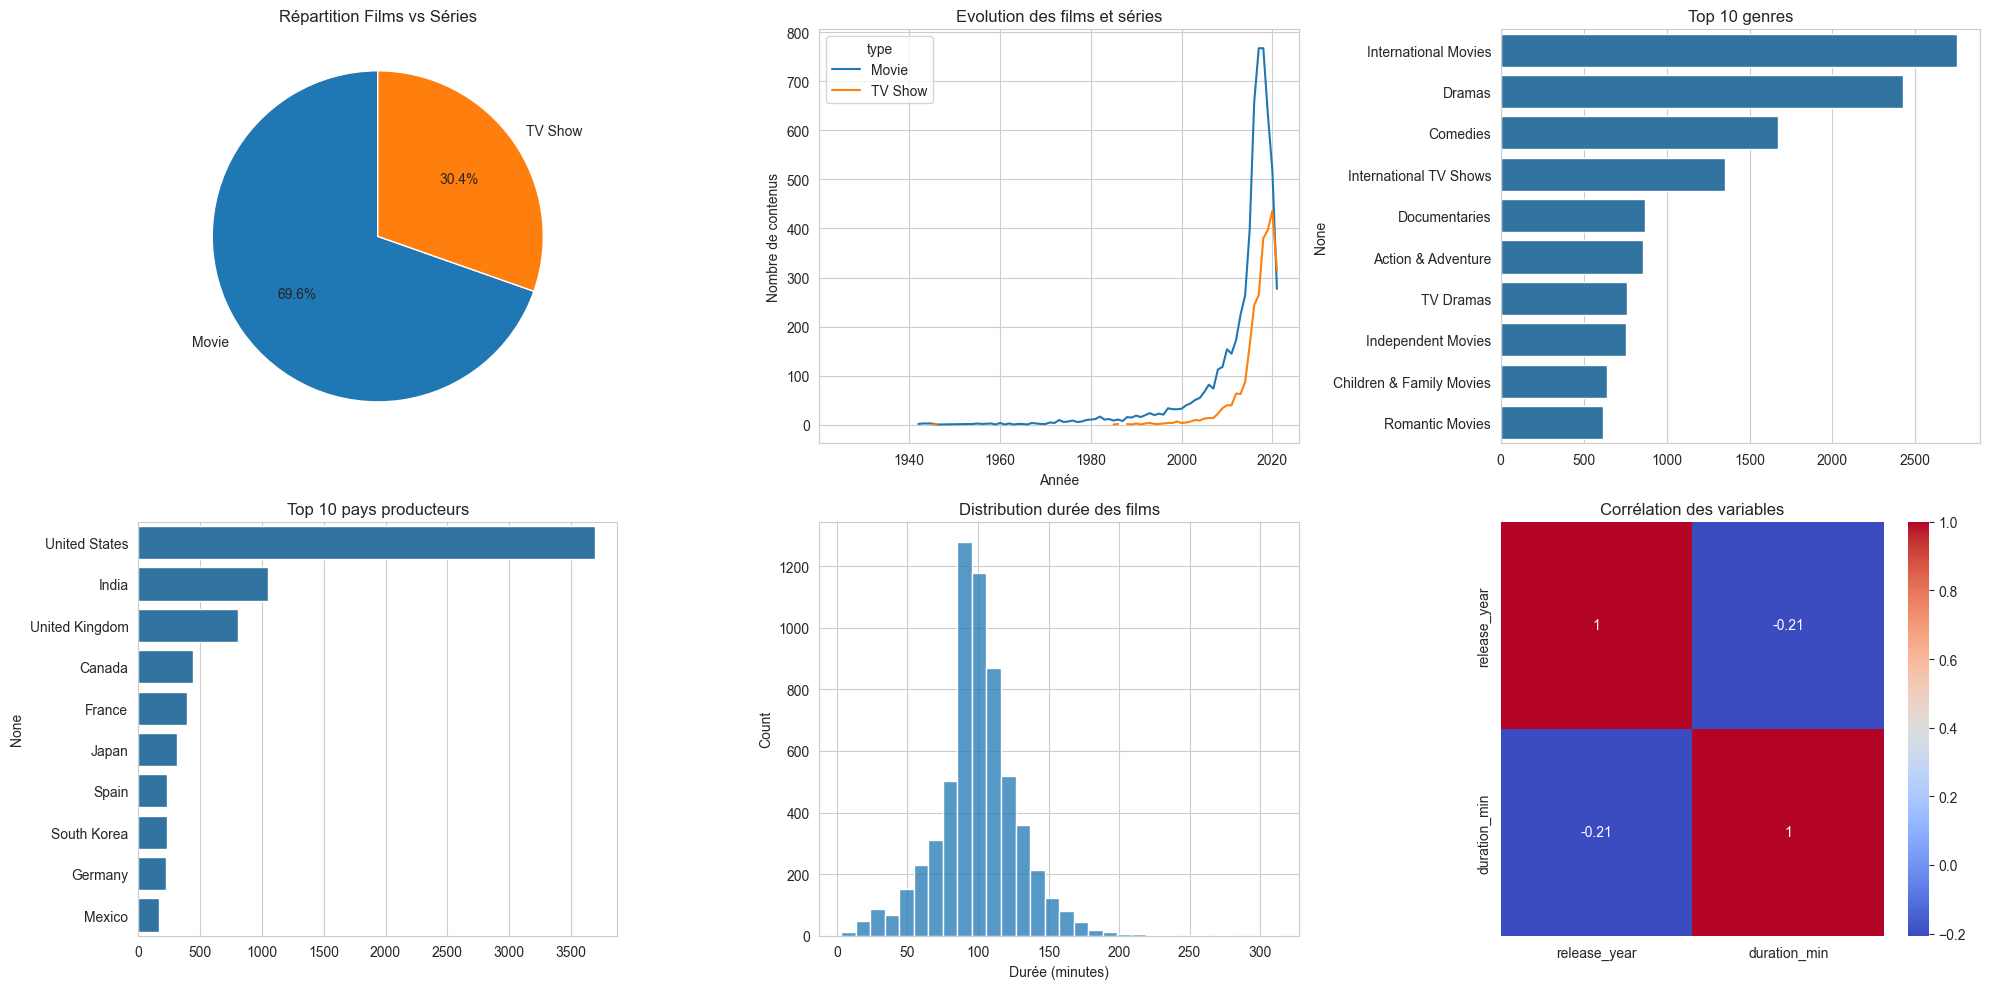

In [74]:
# Création du tableau de synthèse (6 graphiques)
fig, axes = plt.subplots(2, 3, figsize=(20,10))

# -----------------------------
# 1 Répartition Films vs Séries
# -----------------------------
content_counts = df['type'].value_counts()

axes[0,0].pie(content_counts,
              labels=content_counts.index,
              autopct='%1.1f%%',
              startangle=90)
axes[0,0].set_title("Répartition Films vs Séries")

# -----------------------------
# 2 Evolution films et séries
# -----------------------------
content_year = df.groupby(['release_year','type']).size().unstack()

content_year.plot(ax=axes[0,1])
axes[0,1].set_title("Evolution des films et séries")
axes[0,1].set_xlabel("Année")
axes[0,1].set_ylabel("Nombre de contenus")

# -----------------------------
# 3 Top 10 genres
# -----------------------------
genres = df['listed_in'].str.split(',', expand=True).stack().str.strip()
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0,2])
axes[0,2].set_title("Top 10 genres")

# -----------------------------
# 4 Top 10 pays
# -----------------------------
countries = df['country'].str.split(',', expand=True).stack().str.strip()
top_countries = countries.value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1,0])
axes[1,0].set_title("Top 10 pays producteurs")

# -----------------------------
# 5 Distribution durée films
# -----------------------------
sns.histplot(df_movies['duration_min'], bins=30, ax=axes[1,1])
axes[1,1].set_title("Distribution durée des films")
axes[1,1].set_xlabel("Durée (minutes)")

# -----------------------------
# 6 Corrélation
# -----------------------------
corr = df_movies[['release_year','duration_min']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,2])
axes[1,2].set_title("Corrélation des variables")

# -----------------------------
# Ajustement
# -----------------------------
plt.tight_layout()
plt.show()

Tableau de synthèse des principales analyses exploratoires réalisées sur le catalogue Netflix. Ces visualisations permettent d’avoir 
une vue globale des caractéristiques du dataset : structure du catalogue, évolution dans le temps, genres dominants, pays producteurs,
durée des films et relations entre variables.

## Etape 3 :Analyse Approfondie

L'exploration des données a permis d'observer plusieurs caractéristiques du catalogue Netflix, notamment la répartition des contenus, les principaux pays producteurs et les genres dominants.

Cependant, parmi ces différentes dimensions, la durée des films constitue une caractéristique particulièrement intéressante à analyser dans le temps. Alors on va  concentrer sur cette variable pour répondre à la question suivante :  la durée des films a-t-elle
évolué au fil du temps ? cette section vise à analyser cette relation de manière plus approfondie.

### Question de recherche

La durée des films présents sur Netflix a-t-elle évolué au fil du temps ?

Dans cette section, nous cherchons à analyser si les caractéristiques des films,et en particulier leur durée, ont changé au fil des années dans le catalogue Netflix.
Avec l'augmentation importante du nombre de contenus disponibles sur la plateforme,il est intéressant d'examiner si le format des films a également évolué.

Pour répondre à cette question, nous analysons la relation entre l'année de sortie et la durée des films à l'aide de plusieurs visualisations : un scatter plot avec ligne de tendance, une comparaison des durées selon différentes périodes et l'évolution de la durée moyenne des films au fil du temps.

### - Relation entre l'année de sortie et la durée des films

Afin d'observer si la durée des films a évolué au fil du temps, nous analysons la relation entre l'année de sortie des 
films et leur durée. Le graphique suivant représente chaque film par un point et inclut une ligne de tendance permettant de visualiser l'évolution générale de la durée des films au fil des années.



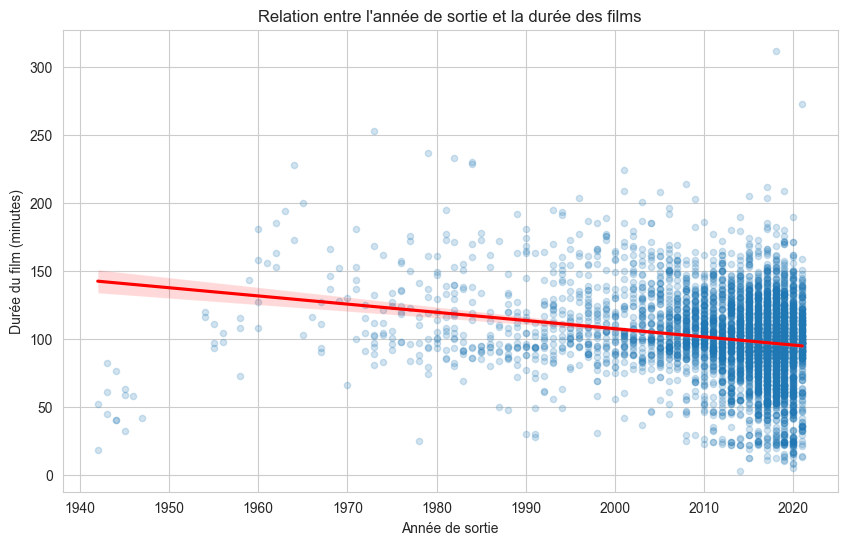

In [79]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_movies,
    x='release_year',
    y='duration_min',
    scatter_kws={'alpha':0.2, 's':20},
    line_kws={'color':'red'}
)

plt.title("Relation entre l'année de sortie et la durée des films")
plt.xlabel("Année de sortie")
plt.ylabel("Durée du film (minutes)")

plt.show()

#### Interprétation

Ce graphique montre la relation entre l’année de sortie des films et leur durée. Chaque point représente un film, tandis que la ligne rouge correspond à la tendance générale estimée à partir des données.

On observe que la majorité des films se situe entre 80 et 120 minutes, quelle que soit l’année de sortie. Cela indique que la durée standard des films reste relativement stable dans le temps.

Cependant, la ligne de tendance présente une légère pente négative, suggérant que la durée moyenne des films tend à diminuer légèrement au fil des années. Cette tendance peut être liée à l’évolution des formats de consommation des contenus, notamment avec l’essor des plateformes de streaming où les formats plus courts peuvent être privilégiés.

Enfin, on remarque également une concentration plus importante de films dans les années récentes, ce qui reflète l’augmentation significative du nombre de contenus disponibles sur Netflix au cours des dernières années.

### - Distribution de la durée des films selon les périodes

Pour analyser plus précisément l'évolution de la durée des films, on regroupe les films par grandes périodes historiques. Cette approche permet de comparer la distribution des durées des films selon différentes périodes et d'identifier d'éventuelles variations dans le format des films.

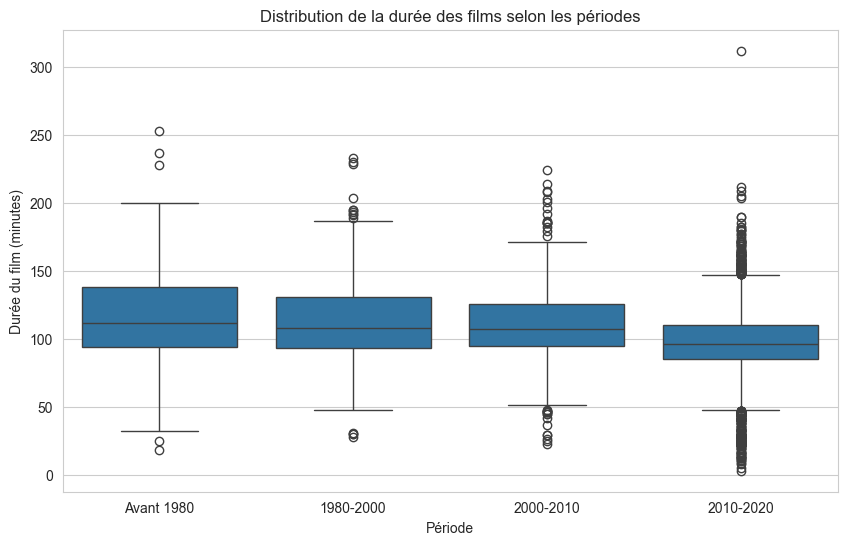

In [80]:
df_movies['periode'] = pd.cut(
    df_movies['release_year'],
    bins=[1920,1980,2000,2010,2020],
    labels=['Avant 1980','1980-2000','2000-2010','2010-2020']
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_movies,
    x='periode',
    y='duration_min'
)

plt.title("Distribution de la durée des films selon les périodes")
plt.xlabel("Période")
plt.ylabel("Durée du film (minutes)")

plt.show()

#### Interprétation

Ce graphique compare la distribution de la durée des films selon différentes périodes de sortie. Les boxplots permettent d’observer la médiane, la dispersion des données ainsi que les valeurs extrêmes pour chaque période.

On constate que la médiane de la durée des films reste relativement stable au fil du temps, généralement située autour de 100 minutes. Cela indique que le format standard des films n’a pas connu de transformation majeure entre les différentes périodes.

Cependant, on observe une légère diminution de la durée médiane pour la période la plus récente (2010-2020). Cette tendance suggère que les films récents présents sur Netflix peuvent être légèrement plus courts en moyenne.

Par ailleurs, la présence de nombreux points extrêmes (outliers) montre qu’il existe toujours des films beaucoup plus longs ou beaucoup plus courts que la moyenne, ce qui reflète la diversité des formats de contenus disponibles sur la plateforme.

### - Évolution de la durée moyenne des films avec moyenne mobile

Afin de mieux observer la tendance générale dans l'évolution de la durée des films,
on applique une moyenne mobile sur plusieurs années. Cette technique permet de lisser les fluctuations annuelles et de mettre en évidence la tendance globale dans les données.

La moyenne mobile utilisée ici est calculée sur une fenêtre de 5 années.
Elle permet de mieux visualiser l'évolution progressive de la durée moyenne des films au fil du temps.

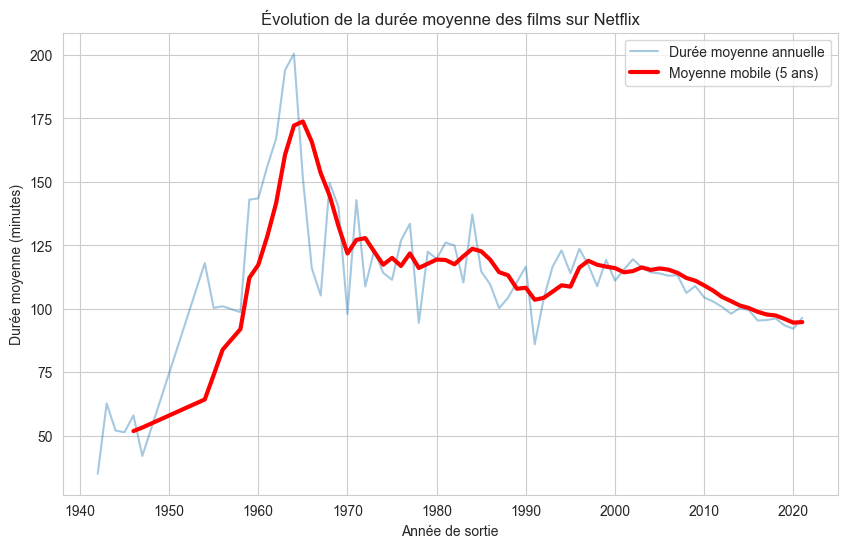

In [83]:
# Calcul de la durée moyenne des films par année
avg_duration = df_movies.groupby('release_year')['duration_min'].mean()

# Calcul de la moyenne mobile sur 5 ans
moving_avg = avg_duration.rolling(window=5).mean()

# Création du graphique
plt.figure(figsize=(10,6))

# Courbe originale
plt.plot(avg_duration, alpha=0.4, label="Durée moyenne annuelle")

# Moyenne mobile
plt.plot(moving_avg, color='red', linewidth=3, label="Moyenne mobile (5 ans)")

plt.title("Évolution de la durée moyenne des films sur Netflix")
plt.xlabel("Année de sortie")
plt.ylabel("Durée moyenne (minutes)")

plt.legend()

plt.show()

#### Interprétation

Ce graphique présente l’évolution de la durée moyenne des films par année de sortie. 
La courbe bleue correspond à la durée moyenne annuelle, tandis que la courbe rouge représente la moyenne mobile sur cinq ans, utilisée pour
lisser les fluctuations et mettre en évidence la tendance générale.

On observe que la durée moyenne des films a connu une forte augmentation entre les années 1950 et le début des années 1960, atteignant un 
pic proche de 170 minutes. 
Après cette période, la durée moyenne diminue progressivement et se stabilise autour de 100 à 120 minutes pendant plusieurs décennies.

Dans les années les plus récentes, la moyenne mobile indique une légère diminution de la durée moyenne des films, qui tend à se rapprocher 
d’environ 95 à 100 minutes. 
Cette tendance peut refléter une adaptation aux nouveaux modes de consommation des contenus sur les plateformes de streaming, où des formats
légèrement plus courts peuvent être privilégiés.

Globalement, ce graphique montre que malgré certaines variations historiques, la durée des films reste relativement stable dans le temps, 
avec une tendance récente à des films légèrement plus courts.

### - Durée moyenne des films selon le genre principal

Afin d’approfondir l’analyse de la durée des films sur Netflix, nous étudions ici la durée moyenne des films selon leur genre principal.

La colonne listed_in  contient souvent plusieurs genres pour un même contenu. Afin de simplifier l’analyse et d’éviter une fragmentation 
excessive des catégories, seul le genre principal (le premier genre listé) est conservé pour cette visualisation.

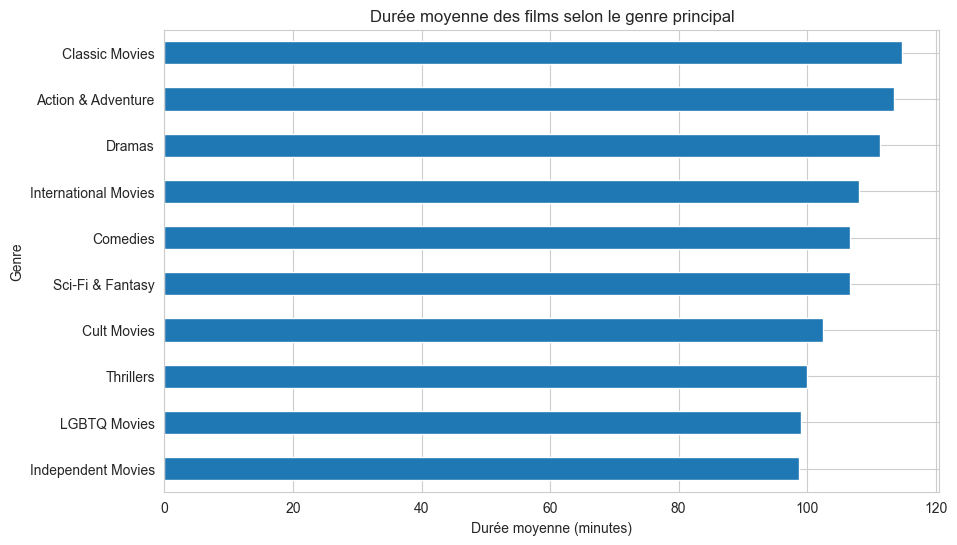

In [88]:
# Garder uniquement les films
df_movies = df[df['type'] == 'Movie'].copy()

# Extraire la durée en minutes
df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)')
df_movies = df_movies.dropna(subset=['duration_min'])
df_movies['duration_min'] = df_movies['duration_min'].astype(int)

# Extraire le genre principal
df_movies['main_genre'] = df_movies['listed_in'].str.split(',').str[0].str.strip()

# Calculer la durée moyenne par genre
genre_duration = (
    df_movies.groupby('main_genre')['duration_min']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Tracer le graphique
plt.figure(figsize=(10,6))
genre_duration.sort_values().plot(kind='barh')

plt.title("Durée moyenne des films selon le genre principal")
plt.xlabel("Durée moyenne (minutes)")
plt.ylabel("Genre")

plt.show()

#### Interprétation

Ce graphique montre que la durée moyenne des films varie selon le genre principal.

Certains genres présentent une durée moyenne plus élevée que d’autres, ce qui suggère que la structure du catalogue peut influencer
la durée moyenne globale des films sur Netflix.

Ainsi, l’évolution de la durée moyenne des films au fil du temps peut en partie s’expliquer par l’évolution des genres dominants dans 
le catalogue. Si Netflix propose davantage de films appartenant à des genres généralement plus courts, la durée moyenne globale tend 
naturellement à diminuer.

### Analyse des séries TV : nombre de saisons

Afin de compléter l’analyse centrée sur les films, on étudie ici les séries TV présentes dans le catalogue Netflix.  
La colonne `duration` indique généralement le nombre de saisons pour chaque série. Cette analyse permet d’observer la structure des séries
disponibles sur la plateforme.

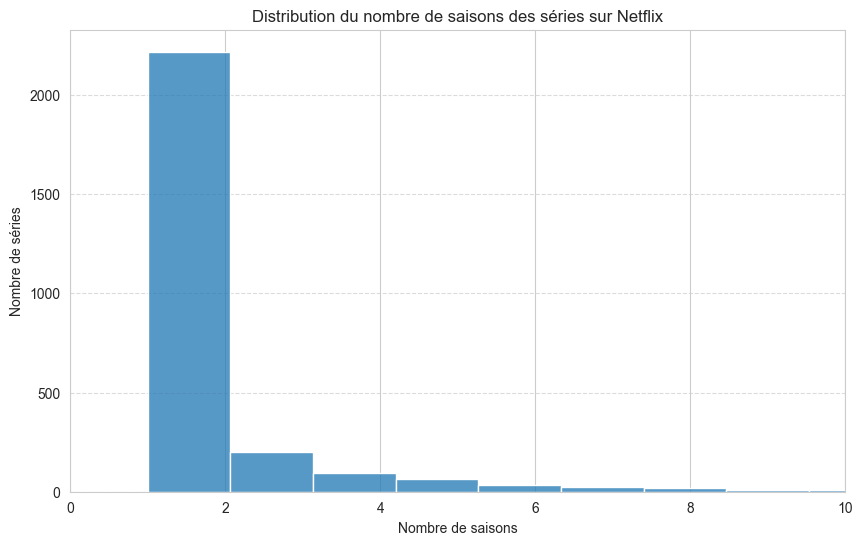

In [92]:
# Filtrer uniquement les séries
df_series = df[df['type'] == 'TV Show'].copy()

# Extraire le nombre de saisons
df_series['seasons'] = df_series['duration'].str.extract(r'(\d+)')
df_series = df_series.dropna(subset=['seasons'])
df_series['seasons'] = df_series['seasons'].astype(int)

# Histogramme du nombre de saisons
plt.figure(figsize=(10,6))
sns.histplot(df_series['seasons'], bins=15)

plt.title("Distribution du nombre de saisons des séries sur Netflix")
plt.xlabel("Nombre de saisons")
plt.ylabel("Nombre de séries")

plt.xlim(0,10)  # on limite l'axe pour mieux voir la distribution principale
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Interprétation

Ce graphique montre la distribution du nombre de saisons des séries présentes sur Netflix.

On observe que la grande majorité des séries comporte seulement une ou deux saisons. Les séries ayant un nombre élevé de saisons sont 
beaucoup plus rares et représentent une proportion très faible du catalogue.

Cette distribution indique que le catalogue Netflix est majoritairement composé de séries relativement courtes. Cela peut s’expliquer par 
la stratégie des plateformes de streaming qui privilégient souvent des séries limitées ou des productions plus courtes afin de renouveler
régulièrement les contenus proposés aux utilisateurs.

La présence d’un petit nombre de séries avec un grand nombre de saisons montre néanmoins que certaines productions plus longues existent
dans le catalogue, mais elles restent marginales par rapport à l’ensemble des séries disponibles.

### Insights et conclusions

#### Résultats principaux

L'analyse montre que la durée des films présents sur Netflix reste globalement stable au fil du temps. La majorité des films se situe entre environ 90 et 110 minutes, ce qui correspond au format classique du cinéma. Malgré l’augmentation importante du nombre de contenus disponibles sur la plateforme au cours des dernières années, la structure générale de la durée des films ne semble pas avoir changé de manière radicale.

Les visualisations mettent cependant en évidence une légère tendance à la diminution de la durée moyenne des films dans les années récentes. La ligne de tendance du scatter plot ainsi que la moyenne mobile de la série temporelle suggèrent que les films récents sont légèrement plus courts en moyenne.

L’analyse par genre montre également que la durée moyenne varie selon le type de film. Certains genres présentent des durées moyennes plus élevées que d’autres, ce qui indique que la composition du catalogue en termes de genres peut influencer la durée moyenne globale des films.

L’analyse des séries TV met en évidence que la majorité des séries présentes sur Netflix comporte un nombre limité de saisons, le plus souvent entre une et deux saisons. Les séries comportant un grand nombre de saisons sont beaucoup plus rares. Cette distribution suggère que le catalogue est principalement composé de séries relativement courtes, ce qui correspond à une stratégie de renouvellement régulier des contenus sur les plateformes de streaming.

#### Surprises dans les données

Une observation intéressante est la grande variabilité de la durée des films. Bien que la durée moyenne reste relativement stable, on observe de nombreux films plus courts ou plus longs que la moyenne. Cette dispersion montre que Netflix propose une grande diversité
de formats et de types de contenus.

De plus, la distribution du nombre de saisons des séries est fortement asymétrique : la majorité des séries comporte peu de saisons, tandis qu’un petit nombre de séries seulement possède un grand nombre de saisons. Cela met en évidence une structure de catalogue majoritairement composée de séries récentes ou de productions limitées.

#### Recommandations

Ces résultats suggèrent que Netflix pourrait continuer à proposer une diversité de durées de films et de formats de séries afin de répondre aux différentes préférences des spectateurs. La légère tendance vers des films plus courts pourrait refléter une adaptation aux nouvelles habitudes de consommation des utilisateurs, notamment sur les plateformes de streaming où les contenus plus courts peuvent être plus facilement consommés. Dans cette perspective, il serait pertinent pour Netflix de continuer à enrichir son catalogue avec des films de formats variés afin de s'adapter aux différents marchés et publics cibles.
L'analyse du nombre de saisons montre également que les séries courtes occupent une place importante dans le catalogue. Maintenir un équilibre entre séries courtes et séries plus longues pourrait permettre de satisfaire différents types d'audience, certains spectateurs préférant des contenus rapides à regarder tandis que d'autres privilégient des séries plus longues et immersives. Enfin, améliorer la qualité et la complétude des métadonnées de durée pour les contenus les plus récents permettrait d'affiner ce type d'analyse à l'avenir.

#### Limitations de l’analyse

Cette analyse présente certaines limitations. Tout d'abord, les données utilisées ne représentent qu'un échantillon du catalogue Netflix et ne reflètent pas nécessairement l'ensemble des contenus disponibles. De plus, l'analyse se concentre principalement sur la durée des films, le genre principal et le nombre de saisons des séries. Il convient également de noter que les données post-2020 sont incomplètes dans ce dataset, ce qui introduit un biais dans l'interprétation des tendances les plus récentes et peut conduire à sous-estimer la production de contenus sur cette période.
Par ailleurs, la colonne listed_in contenant souvent plusieurs genres par contenu, l'analyse par genre principal ne retient que le premier genre listé, ce qui peut sous-représenter certaines catégories et fausser légèrement les comparaisons de durée par genre. D'autres facteurs comme le pays de production, la popularité des contenus ou la date d'ajout sur la plateforme pourraient également influencer la structure du catalogue. Enfin, l'absence de données sur les vues ou les notes des utilisateurs empêche d'évaluer la popularité réelle des contenus, ce qui limite les conclusions que l'on peut tirer sur les préférences du public. Une analyse plus approfondie intégrant davantage de variables permettrait d'obtenir une compréhension plus complète des tendances du catalogue Netflix.